# Inspect, select, and visualize JSONL fitness landscapes

This notebook treats every JSONL field as **data**, validates the files, randomly selects three executable individuals, and plots each objective as a 3D surface with a 2D contour projection on the floor. Basin locations from `basin_info` are overlaid when present.

Eligibility rule: finite numeric score, empty `error`, syntactically valid numerical Python code, and successful evaluation in two dimensions. When top-level `fitness > 1`, `metadata.raw_fitness` is used as the reported score; otherwise top-level `fitness` is used. Three eligible records are sampled uniformly at random with a configurable seed.

In [39]:
from pathlib import Path
import ast
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

# These are the user-provided files. Add more paths to this list as needed.
JSONL_FILES = [
    Path("/local/bodasap/LLaMEA/basinsattribution-main/outputs/local/exp-06-08_131250-LLaMEA-multi-llm-ELA-NOT Basins.jsonl"),
]
JSONL_FILES = [path.expanduser().resolve() for path in JSONL_FILES]

assert JSONL_FILES and all(path.is_file() for path in JSONL_FILES), "One or more JSONL paths do not exist."
print(f"Found {len(JSONL_FILES)} JSONL file(s):")
for path in JSONL_FILES:
    print(" -", path)

Found 1 JSONL file(s):
 - /local/bodasap/LLaMEA/basinsattribution-main/outputs/local/exp-06-08_131250-LLaMEA-multi-llm-ELA-NOT Basins.jsonl


## 1. Check and summarize the JSONL files

In [40]:
REQUIRED_FIELDS = {"id", "fitness", "name", "code"}
records, issues = [], []

for path in JSONL_FILES:
    with path.open(encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError as exc:
                issues.append((path.name, line_number, f"invalid JSON: {exc.msg}"))
                continue
            missing = REQUIRED_FIELDS - record.keys()
            if missing:
                issues.append((path.name, line_number, f"missing fields: {sorted(missing)}"))
                continue
            record["_source"] = str(path)
            record["_line"] = line_number
            records.append(record)

print(f"Loaded {len(records)} structurally valid record(s); found {len(issues)} issue(s).")
for issue in issues[:10]:
    print("ISSUE:", issue)
if len(issues) > 10:
    print(f"... and {len(issues) - 10} more")

Loaded 9 structurally valid record(s); found 0 issue(s).


## 2. Validate and randomly select three individuals

The generated source is untrusted input. The validator below only admits a small numerical subset: NumPy import, class/function definitions, assignments, arithmetic, and selected NumPy calls. It rejects file/network/process access and other imports before execution.

In [41]:
ALLOW_ALL_CALLS = True  # Allow arbitrary call forms; import and built-in restrictions still apply.

ALLOWED_NUMPY_CALLS = {
    "abs", "arange", "array", "arctan", "asarray", "atleast_1d",
    "ceil", "clip", "cos", "cosh", "exp", "floor", "fromiter",
    "heaviside", "linspace", "log", "log1p", "maximum", "minimum",
    "ones_like", "power", "reshape", "sign", "sin", "sinh",
    "sqrt", "square", "sum", "tan", "tanh", "where", "zeros_like"
}
ALLOWED_QUALIFIED_NUMPY_CALLS = {"np.random.default_rng", "np.random.uniform"}
ALLOWED_METHOD_CALLS = {"append", "copy", "reshape"}
ALLOWED_BUILTIN_CALLS = {
    "ValueError", "abs", "enumerate", "float", "int", "len",
    "max", "min", "pow", "range", "sum", "zip"
}
FORBIDDEN_NODES = (ast.AsyncFunctionDef, ast.Await, ast.Delete, ast.Global, ast.Lambda,
                   ast.Nonlocal, ast.Try, ast.With, ast.Yield, ast.YieldFrom)

def validate_source(source):
    tree = ast.parse(source)
    for node in ast.walk(tree):
        if isinstance(node, FORBIDDEN_NODES):
            raise ValueError(f"forbidden syntax: {type(node).__name__}")
        if isinstance(node, (ast.Import, ast.ImportFrom)):
            names = [alias.name for alias in node.names]
            if isinstance(node, ast.ImportFrom) or names != ["numpy"]:
                raise ValueError(f"only 'import numpy as np' is allowed; got {names}")
        if isinstance(node, ast.Name) and node.id.startswith("__"):
            raise ValueError("dunder names are forbidden")
        if isinstance(node, ast.Attribute) and node.attr.startswith("__"):
            raise ValueError("dunder attributes are forbidden")
        if isinstance(node, ast.Call):
            if ALLOW_ALL_CALLS:
                continue
            func = node.func
            if isinstance(func, ast.Name):
                if func.id not in ALLOWED_BUILTIN_CALLS:
                    raise ValueError(f"call to {func.id!r} is not allowed")
            elif isinstance(func, ast.Attribute):
                parts, root = [], func
                while isinstance(root, ast.Attribute):
                    parts.append(root.attr)
                    root = root.value
                qualified = (root.id + "." + ".".join(reversed(parts))) if isinstance(root, ast.Name) else ""
                direct_numpy = (isinstance(func.value, ast.Name) and func.value.id == "np"
                                and func.attr in ALLOWED_NUMPY_CALLS)
                safe_qualified_numpy = qualified in ALLOWED_QUALIFIED_NUMPY_CALLS
                safe_container_method = func.attr in ALLOWED_METHOD_CALLS
                safe_self_helper = (isinstance(func.value, ast.Name) and func.value.id == "self"
                                    and not func.attr.startswith("__"))
                if not (direct_numpy or safe_qualified_numpy or safe_container_method or safe_self_helper):
                    raise ValueError(f"call to {qualified or func.attr!r} is not allowed")
            else:
                raise ValueError("dynamic calls are not allowed")
    return tree

def build_objective(record):
    tree = validate_source(record["code"])
    class_names = [node.name for node in tree.body if isinstance(node, ast.ClassDef)]
    if len(class_names) != 1:
        raise ValueError(f"expected exactly one class, found {len(class_names)}")
    # Import is already AST-restricted to NumPy. Keep the execution namespace minimal.
    namespace = {"np": np, "__name__": "validated_landscape",
                 "__builtins__": {"__import__": __import__, "__build_class__": __build_class__,
                 "object": object, "staticmethod": staticmethod, "ValueError": ValueError,
                 "abs": abs, "enumerate": enumerate,
                 "float": float, "int": int, "len": len, "max": max,
                 "min": min, "pow": pow, "range": range, "sum": sum, "zip": zip}}
    exec(compile(tree, record["_source"], "exec"), namespace)
    instance = namespace[class_names[0]](dim=2)
    if not callable(getattr(instance, "f", None)):
        raise ValueError("class has no callable f method")
    probe = float(instance.f(np.array([0.123, -0.456])))
    if not np.isfinite(probe):
        raise ValueError("non-finite result on probe point")
    return instance.f

eligible, rejected = [], []
for record in records:
    try:
        fitness = float(record["fitness"])
        if not math.isfinite(fitness):
            raise ValueError("fitness is not finite")
        if fitness > 1:
            raw_fitness = record.get("metadata", {}).get("raw_fitness")
            if raw_fitness is None:
                raise ValueError("fitness > 1 but metadata.raw_fitness is missing")
            selection_fitness = float(raw_fitness)
        else:
            selection_fitness = fitness
        if not math.isfinite(selection_fitness):
            raise ValueError("selection fitness is not finite")
        if str(record.get("error", "")).strip():
            raise ValueError(f"record has error: {record['error']}")
        record["_selection_fitness"] = selection_fitness
        record["_objective"] = build_objective(record)
        eligible.append(record)
    except Exception as exc:
        rejected.append((record.get("id"), record.get("name"), str(exc)))

print(f"Eligible: {len(eligible)}; rejected: {len(rejected)}")
if rejected:
    print("First rejected records:")
    for item in rejected[:10]:
        print(" -", item)
assert len(eligible) >= 3, f"Only {len(eligible)} eligible individual(s); need three. See rejection reasons above."
RANDOM_SEED = 43  # Change this to draw a different reproducible sample.
rng = np.random.default_rng(RANDOM_SEED)
selected = [eligible[i] for i in rng.choice(len(eligible), size=3, replace=False)]
print(f"\nRandomly selected individuals (seed={RANDOM_SEED}):")
for rank, record in enumerate(selected, start=1):
    print(f"{rank}. {record['name']} | selection score={record['_selection_fitness']:.6g} "
          f"| original fitness={float(record['fitness']):.6g} | id={record['id']}")

Eligible: 8; rejected: 1
First rejected records:
 - ('0512f3b0-e26c-4b40-bc6d-601ce63fa159', 'RadialScaleLandscape', "name 'isinstance' is not defined")

Randomly selected individuals (seed=43):
1. FractalValley | selection score=0.89064 | original fitness=9.84479 | id=d15c8229-d899-4847-afa0-ccca40773552
2. landscape | selection score=0.336413 | original fitness=18.6404 | id=d1624e54-4445-49f7-a397-fdf4c5946505
3. HeteroScaleLandscape | selection score=0.000409861 | original fitness=10.7766 | id=8d8cd8f2-7e37-48e6-b079-03f953ee634a


## 3. Plot the 3D landscapes and their 2D projections

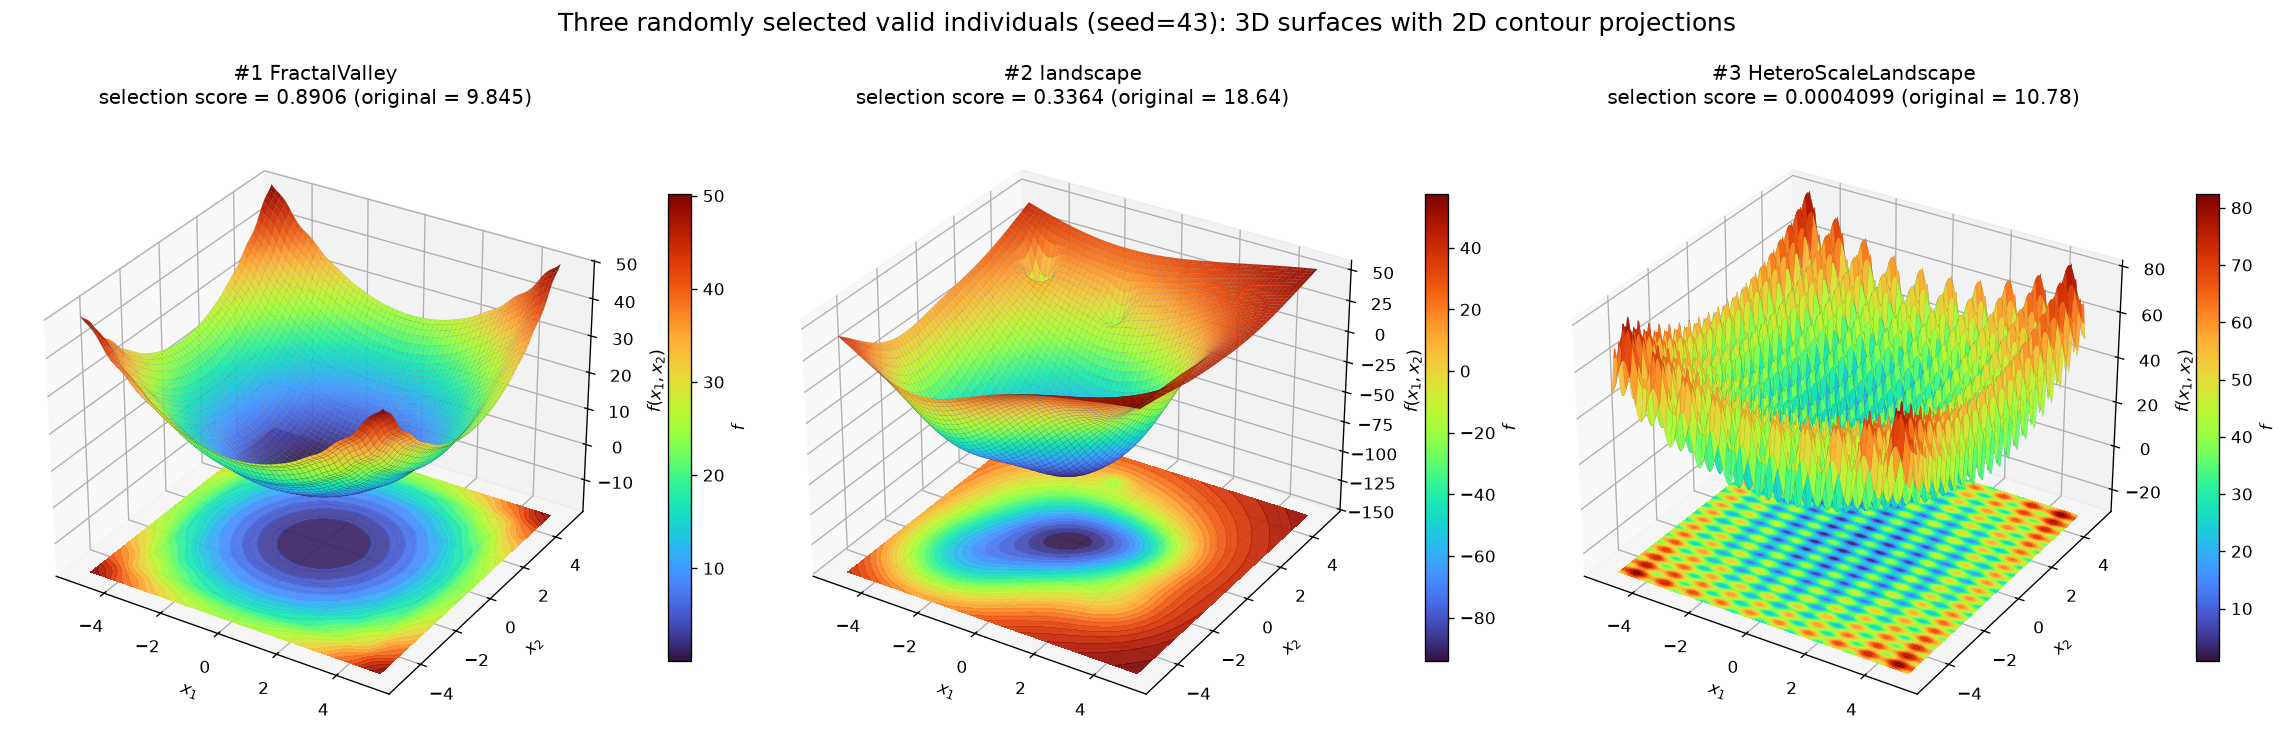

In [42]:
LOWER, UPPER = -5.0, 5.0
GRID_SIZE = 180
SHOW_BASIN_MARKS = False  # Set to False to hide basin markers.
axis_values = np.linspace(LOWER, UPPER, GRID_SIZE)
X1, X2 = np.meshgrid(axis_values, axis_values)
points = np.column_stack([X1.ravel(), X2.ravel()])

def evaluate_grid(objective, points):
    # Generated functions generally accept one point at a time.
    return np.fromiter((float(objective(p)) for p in points), dtype=float, count=len(points))

fig = plt.figure(figsize=(19, 6.5), constrained_layout=True)

for panel, record in enumerate(selected, start=1):
    ax = fig.add_subplot(1, 3, panel, projection="3d")
    Z = evaluate_grid(record["_objective"], points).reshape(X1.shape)
    finite = Z[np.isfinite(Z)]
    if finite.size != Z.size:
        warnings.warn(f"{record['name']}: replacing non-finite grid values")
        Z = np.nan_to_num(Z, nan=np.nanmedian(finite), posinf=np.nanmax(finite), neginf=np.nanmin(finite))

    z_min, z_max = float(Z.min()), float(Z.max())
    span = max(z_max - z_min, np.finfo(float).eps)
    floor = z_min - 0.38 * span
    norm = Normalize(vmin=z_min, vmax=z_max)

    ax.plot_surface(X1, X2, Z, cmap="turbo", norm=norm, rstride=3, cstride=3,
                    linewidth=0.15, edgecolor=(0, 0, 0, 0.22), antialiased=True, alpha=0.96)
    ax.contourf(X1, X2, Z, levels=30, zdir="z", offset=floor, cmap="turbo", norm=norm, alpha=0.9)
    ax.contour(X1, X2, Z, levels=20, zdir="z", offset=floor, colors="k", linewidths=0.3, alpha=0.65)

    basins = record.get("basin_info") or []
    basin_xy = np.asarray([b[1][:2] for b in basins if len(b) > 1 and len(b[1]) >= 2], dtype=float)
    if SHOW_BASIN_MARKS and basin_xy.size:
        inside = np.all((basin_xy >= LOWER) & (basin_xy <= UPPER), axis=1)
        basin_xy = basin_xy[inside]
        if len(basin_xy):
            basin_z = evaluate_grid(record["_objective"], basin_xy)
            ax.scatter(basin_xy[:, 0], basin_xy[:, 1], basin_z, marker="+", s=45,
                       c="magenta", linewidths=1.2, depthshade=False)
            ax.scatter(basin_xy[:, 0], basin_xy[:, 1], np.full(len(basin_xy), floor),
                       marker="+", s=35, c="red", linewidths=1.0, depthshade=False)

    ax.set(xlabel=r"$x_1$", ylabel=r"$x_2$", zlabel=r"$f(x_1,x_2)$", zlim=(floor, z_max))
    ax.set_title(f"#{panel} {record['name']}\nselection score = {record['_selection_fitness']:.4g} "
                 f"(original = {float(record['fitness']):.4g})", pad=12)
    ax.view_init(elev=30, azim=-58)
    fig.colorbar(ScalarMappable(norm=norm, cmap="turbo"), ax=ax, shrink=0.66, pad=0.08, label=r"$f$")

fig.suptitle(f"Three randomly selected valid individuals (seed={RANDOM_SEED}): 3D surfaces with 2D contour projections", fontsize=15)
plt.show()

### Notes

- Change `JSONL_FILES` in the first code cell to analyze a specific subset.
- Selection is uniform random sampling without replacement from eligible records. Change `RANDOM_SEED` to obtain another reproducible sample.
- The displayed score uses `metadata.raw_fitness` when top-level `fitness > 1`; otherwise it uses top-level `fitness`. The objective function `f` itself remains a minimization landscape.
- The floor contours are the requested 2D projection. Set `SHOW_BASIN_MARKS = False` to hide the magenta/red basin symbols on the surface and projection.